# Figure 3

## Define data loading, fitting, and plotting functions


In [1]:
"""
600 °C collapse figure for SS316H: compares nominal stress, fractal stress,
and the proposed temperature-dependent geometry-corrected stress.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from scipy.optimize import minimize, minimize_scalar


# ----------------------------------------------------------------------
# DATA LOADING
# ----------------------------------------------------------------------
def load_data(path, sheet="Data", header=1):
    df = pd.read_excel(path, sheet_name=sheet, header=header)
    d = pd.DataFrame({
        "alloy": df.iloc[:, 2].astype(str).str.strip(),
        "notch": df.iloc[:, 48].astype(str).str.strip(),
        "ssize": df.iloc[:, 43].astype(str).str.strip(),
        "shp":   df.iloc[:, 42].astype(str).str.strip(),
        "b":     pd.to_numeric(df.iloc[:, 46], errors="coerce"),
        "A":     pd.to_numeric(df.iloc[:, 50], errors="coerce"),
        "LD":    pd.to_numeric(df.iloc[:, 49], errors="coerce"),
        "sigma": pd.to_numeric(df.iloc[:, 53], errors="coerce"),
        "temp":  pd.to_numeric(df.iloc[:, 54], errors="coerce"),
        "tR":    pd.to_numeric(df.iloc[:, 55], errors="coerce"),
    })
    m = ((d.notch == "unnotched") & (d.sigma > 0) & (d.tR > 0) &
         (d.temp > 0) & (d.b > 0) & (d.A > 0) & (d.LD > 0))
    return d[m].dropna(subset=["b", "A", "LD"]).reset_index(drop=True)


# ----------------------------------------------------------------------
# FITTING HELPERS
# ----------------------------------------------------------------------
def fit_sigmaT(s, lam=0.1):
    s = s.reset_index(drop=True)
    b0, A0, L0 = s.b.median(), s.A.median(), s.LD.median()
    mu, sd = s.temp.mean(), s.temp.std()
    lb = np.log10(s.b / b0).values
    lA = np.log10(s.A / A0).values
    lL = np.log10(s.LD / L0).values
    lsig = np.log10(s.sigma).values
    y = np.log10(s.tR).values
    Tn = ((s.temp - mu) / sd).values
    tr = s.temp.round().astype(int).values
    groups = [np.where(tr == t)[0] for t in np.unique(tr)]

    def collapse_rss(lx):
        r = 0.0
        for ii in groups:
            if len(ii) < 4:
                r += ((y[ii] - y[ii].mean())**2).sum(); continue
            x = lx[ii]; yy = y[ii]
            Sxx = ((x - x.mean())**2).sum()
            if Sxx < 1e-12:
                r += ((yy - yy.mean())**2).sum(); continue
            Sxy = ((x - x.mean()) * (yy - yy.mean())).sum()
            r += ((yy - yy.mean())**2).sum() - Sxy*Sxy/Sxx
        return r

    def obj(th):
        a0, a1, bb0, bb1, g0, g1 = th
        lx = lsig + (a0+a1*Tn)*lb + (bb0+bb1*Tn)*lA + (g0+g1*Tn)*lL
        return collapse_rss(lx)/len(y) + lam*np.mean((lx - lsig)**2)

    th = minimize(obj, np.zeros(6), method="Nelder-Mead",
                  options={"maxiter": 4000, "xatol": 1e-5, "fatol": 1e-8}).x
    a0, a1, bb0, bb1, g0, g1 = th
    lstar = lsig + (a0+a1*Tn)*lb + (bb0+bb1*Tn)*lA + (g0+g1*Tn)*lL
    return lstar, th, (b0, A0, L0)


def fit_dsigma(g):
    x0 = np.log10(g.sigma.values); y = np.log10(g.tR.values); lb = np.log10(g.b.values)
    def negr2(dd):
        x = x0 + dd*lb
        X = np.column_stack([x, np.ones(len(x))]); bco, *_ = np.linalg.lstsq(X, y, rcond=None)
        return -(1 - ((y - X@bco)**2).sum() / (((y - y.mean())**2).sum()))
    return minimize_scalar(negr2, bounds=(-0.5, 0.5), method="bounded").x


def _r2(x, y):
    X = np.column_stack([x, np.ones(len(x))]); bco, *_ = np.linalg.lstsq(X, y, rcond=None)
    return 1 - ((y - X@bco)**2).sum() / (((y - y.mean())**2).sum()), bco


# ----------------------------------------------------------------------
# FIGURE
# ----------------------------------------------------------------------
def fig_three_600(s_alloy, T=600):
    LABEL_SIZE = 17   # axis labels (x/y)
    TICK_SIZE  = 16   # axis tick values
    TITLE_SIZE = 14   # subplot titles (kept smaller to stay on one line)

    plt.rcParams.update({
        "font.family":     "serif",
        "font.size":       TICK_SIZE,
        "axes.labelsize":  LABEL_SIZE,
        "axes.titlesize":  TITLE_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
    })

    s = s_alloy.copy()
    lstar, *_ = fit_sigmaT(s)
    s = s.assign(lsig=np.log10(s.sigma), lstar=lstar, ltR=np.log10(s.tR))
    g = s[s.temp.round() == T].copy()
    dsig = fit_dsigma(g)
    g["lfrac"] = g.lsig + dsig * np.log10(g.b)

    bmin, bmax = s.b.min(), s.b.max()
    MK = {"Cylindrical": "o", "Flat": "^"}
    leg = [
        Line2D([0],[0], marker="o", color="0.35", ls="", mfc="0.7", mec="k", ms=9, label="Cylindrical"),
        Line2D([0],[0], marker="^", color="0.35", ls="", mfc="0.7", mec="k", ms=9, label="Flat"),
    ]

    fig, ax = plt.subplots(1, 3, figsize=(14.5, 5.0), constrained_layout=True)
    sc = None

    cols = [
        ("lsig",  r"Nominal stress  $\log_{10}\,\sigma$",          "Baseline - nominal stress"),
        ("lfrac", r"Fractal stress  $\log_{10}\,\sigma^{*}$",       "Fractal stress [34]"),
        ("lstar", r"Proposed stress  $\log_{10}\,\sigma^{{*}}_T$",  "Our proposed method"),
    ]

    for c, (xcol, lab, title_tag) in enumerate(cols):
        for shp, mk in MK.items():
            gg = g[g.shp == shp]
            if len(gg):
                sc = ax[c].scatter(
                    gg.ltR, gg[xcol],
                    c=gg.b, cmap="viridis", marker=mk,
                    s=40, edgecolor="k", linewidth=0.3,
                    vmin=bmin, vmax=bmax,
                )
        r2, bco = _r2(g.ltR.values, g[xcol].values)
        xs = np.linspace(g.ltR.min(), g.ltR.max(), 50)
        ax[c].plot(xs, bco[0]*xs + bco[1], "r--", lw=1.5)
        ax[c].set_title(
            f"({'abc'[c]}) {title_tag} ($R^2$ = {r2:.3f})",
            fontweight="bold",
        )
        ax[c].set_xlabel(r"Rupture life $\log_{10} t_r$")
        ax[c].set_ylabel(lab)
        ax[c].grid(alpha=0.25)
        ax[c].legend(handles=leg, title="Specimen shape", loc="lower left", fontsize=10)

    cb = fig.colorbar(sc, ax=ax, fraction=0.022, pad=0.012)
    cb.set_label(
        "Marker colour = characteristic size $b$ (mm)\n(diameter/thickness)",
        fontsize=11,
    )

    plt.show()


## Generate Figure 3


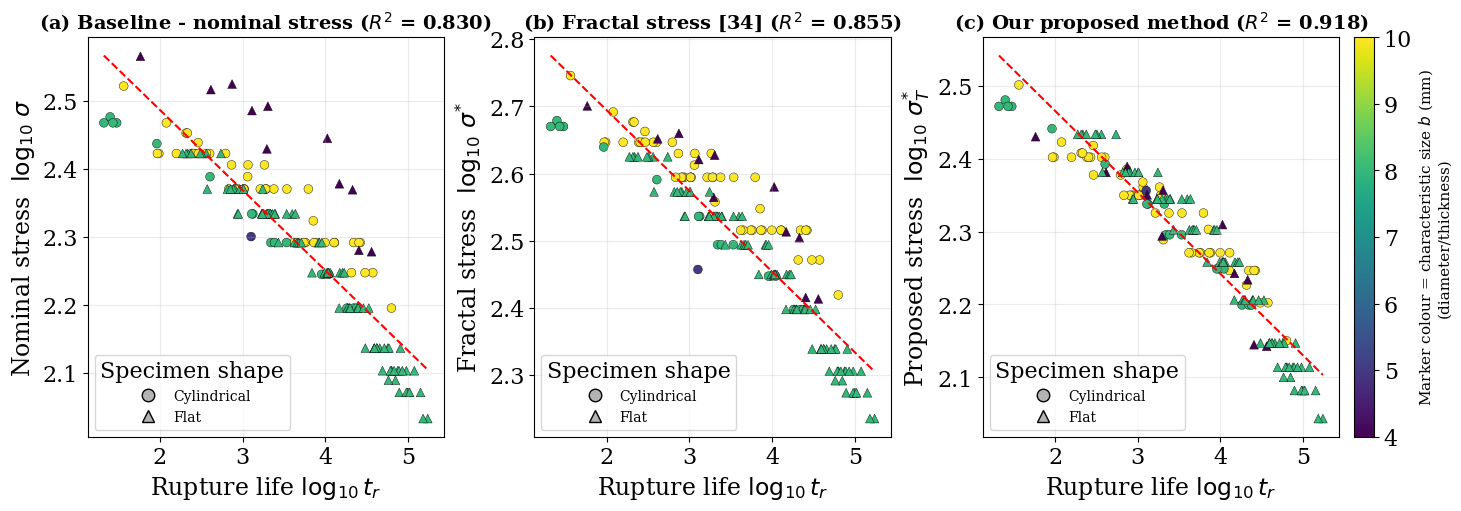

In [2]:
# ----------------------------------------------------------------------
# RUN
# ----------------------------------------------------------------------
PATH = os.path.join("..", "Dataset", "Creep_Properties_Dataset.xlsx")
data = load_data(PATH)
ss316h = data[data.alloy == "SS316H"]
fig_three_600(ss316h, T=600)
